This code serves to visualise the peaks with human input disportion modes. (like isovisq)

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import pandas as pd
from visualiser_function import shift_atoms, transform_list_hkl_p63_p65, get_structure_factors , atom_position_list
from itertools import chain
from matplotlib.markers import MarkerStyle
from tqdm import tqdm
from time import time

In [5]:
#convert the simulated data to log10 scale

def log10(x):
  numerator = tf.math.log(x)
  denominator = tf.math.log(tf.constant(10, dtype=numerator.dtype))
  return numerator / denominator

In [ ]:
def fun_tf(x, pars):
    """
    Fast computation of structure factors with parameter-dependent structure.
        # Get modified structure
    modified_struct = shift_atoms_p65(*pars)
    neg_h = tf.stack([-x[:, 0], x[:, 1], x[:, 2]], axis=1)
    x_combined = tf.concat([x, neg_h], axis=0)  # Shape [2N, 3]

    x_combined = transform_list_hkl_p63_p65(x_combined)

    # Get structure factors
    sf_combined = get_structure_factors(x_combined, modified_struct)
    # Compute intensity
    # Split and compute intensity
    sf_hkl = sf_combined[:tf.shape(x)[0]]
    sf_neg_k = sf_combined[tf.shape(x)[0]:]
    
    intensity = (tf.abs(sf_hkl) + tf.abs(sf_neg_k)) ** 2
    return intensity / tf.reduce_max(intensity)
    """
    # Get modified structure
    atom_shift_list = shift_atoms(*pars)
    print(f"Shape of atom_shift_list: {len(atom_shift_list)}")

    # Flatten atom_shift_list if it contains nested lists
    flat_atom_shift_list = list(chain.from_iterable(
        x if isinstance(x, list) else [x] for x in atom_shift_list
    ))
    modified_struct = atom_position_list(*flat_atom_shift_list)

    #neg_h = tf.stack([-x[:, 0], x[:, 1], x[:, 2]], axis=1)
    x_combined = x
    #x_combined = tf.concat([x, neg_h], axis=0)  # Shape [2N, 3]

    x_combined = transform_list_hkl_p63_p65(x_combined)

    # Get structure factors
    sf_combined = get_structure_factors(x_combined, modified_struct)
    # Compute intensity
    # Split and compute intensity
    # sf_hkl = sf_combined[:tf.shape(x)[0]]
    sf_hkl = sf_combined
    print(f"Shape of sf_hkl: {sf_hkl.shape}, Shape of x_combined: {x_combined.shape}")
    
    intensity = (tf.abs(sf_hkl)) ** 2
    w = tf.constant(0.00048773325893810833, dtype=tf.float32)  # Debye-Waller factor 
    qnorms = tf.norm(tf.cast(x_combined[:tf.shape(x)[0]], tf.float32), axis=1)
    # qnorms = tf.reshape(qnorms, (-1, 1))  # Reshape to match the shape of intensity
    intensity = intensity * tf.exp(-w * qnorms ** 2)  # Apply Debye-Waller factor
    intensity = log10(intensity + 1)  # Convert to log10 scale
    return intensity / tf.reduce_sum(intensity) * 60


In [ ]:
experimental_data = pd.read_csv('C:/Users/User/Desktop/uzh_intern/CrystalClearFit/alrisDistortionFit/PBCO/raw_data/LOGcombined_peaks.csv')
"""
# reduce data to l in [0.5, 1.5, 2.5, 3.5, 4.5 ]
experimental_data = experimental_data[
    (experimental_data["l"] == 0.5) |
    (experimental_data["l"] == 1.5) |
    (experimental_data["l"] == 2.5) |
    (experimental_data["l"] == 3.5) |
    (experimental_data["l"] == 4.5)
]
"""

hkl_list = experimental_data[["h", "k", "l"]].values.tolist()
hkl_list = tf.convert_to_tensor(hkl_list, dtype=tf.float32)
print(experimental_data.shape)
print(hkl_list[0:8])

(13054, 5)
tf.Tensor(
[[ 0.         -0.11111111  0.        ]
 [ 0.         -0.22222222  0.        ]
 [ 0.         -0.33333333  0.        ]
 [ 0.         -0.44444444  0.        ]
 [ 0.         -0.55555556  0.        ]
 [ 0.         -0.66666667  0.        ]
 [ 0.         -0.77777778  0.        ]
 [ 0.         -0.88888889  0.        ]], shape=(8, 3), dtype=float64)


In [8]:

def alris_r_factor(data):
    exp_intensity = data['intensity_exp'] / np.sum(data['intensity_exp']) * 60
    simulated_intensity = data['intensity_sim']
    alris_r_factor = np.sum(np.abs(exp_intensity - simulated_intensity)) / np.sum(np.abs(exp_intensity))
    return alris_r_factor



In [ ]:
n_features = experimental_data.shape[0]
n_dim = 3

features = hkl_list
labels = experimental_data["intensity_exp"].tolist()
vol_err = experimental_data["intensity_exp_err"].tolist()

labels = labels / np.sum(labels) * 60 # Normalize labels

best_model_pars = np.zeros(445, dtype=np.float32)  # Initialize with zeros
best_model_pars = tf.convert_to_tensor(best_model_pars, dtype=tf.float32)   


exp_data = pd.read_csv('C:/Users/User/Desktop/uzh_intern/CrystalClearFit/alrisDistortionFit/PBCO/raw_data/LOGcombined_peaks.csv')
hkl_list = exp_data[["h", "k", "l"]].values.tolist()
hkl_list = tf.convert_to_tensor(hkl_list, dtype=tf.float32)
exp_data['intensity_sim'] = fun_tf(features, best_model_pars).numpy()
#replace values below 1e-5 with 0
exp_data['intensity_sim'] = np.where(exp_data['intensity_sim'] < 8e-4, 0, exp_data['intensity_sim'])

r_factor = alris_r_factor(exp_data)
print(f"ALRIS R-factor: {r_factor:.3f}")

Shape of atom_shift_list: 445
hello world
Shape of sf_hkl: (13054,), Shape of x_combined: (13054, 3)


InvalidArgumentError: cannot compute Mul as input #1(zero-based) was expected to be a float tensor but is a double tensor [Op:Mul]

In [17]:



def plot_plane_sim_vs_exp_DIM2(ax, df,r_factor, norm_plane=False):
    #only extract data for h == 0
    exp_data_0 = df.loc[df['k'] == 0].copy()
    if norm_plane:
        exp_data_0['intensity_exp'] = exp_data_0['intensity_exp'] / np.sum(exp_data_0['intensity_exp']) * 60
    
    ax.scatter(exp_data_0['h'], exp_data_0['l'], 
               s=np.log10(exp_data_0['intensity_sim'] + 1) * 500 , color='red', edgecolor="black",
               label='Sim', marker=MarkerStyle("o", fillstyle="left"))
    ax.scatter(exp_data_0['h'] , exp_data_0['l'] , s=np.log10(exp_data_0['intensity_exp'] + 1) * 500, color='blue', edgecolor="black",
               label='Exp', marker=MarkerStyle("o", fillstyle="right"))
    
    # #grid on
    # ax.grid(True, linestyle='--', alpha=0.7)
    # #adjust x axis ticks
    # ax.set_xticks(np.arange(0, -5, 0.11))
    # ax.set_yticks(np.arange(0, 15, 0.11))
    ax.set_xlabel(f"h in (h, 0, l) [r.l.u.]")
    ax.set_ylabel(f"l in (h, 0, l) [r.l.u.]")
    ax.set_title(f"HL plane for K = 0 (logged) , r-factor: {r_factor:.3f}")
    ax.legend()
    # ax.set_xlim(0 , -5.01)
    # ax.set_ylim(-1.01 , 3)


def plot_plane_sim_vs_exp_DIM1(ax, df, r_factor, norm_plane=False):
    exp_data_0 = df.loc[df['h'] == 0].copy()
    if norm_plane:
        exp_data_0['intensity_exp'] = exp_data_0['intensity_exp'] / np.sum(exp_data_0['intensity_exp']) * 60
    
    ax.scatter(exp_data_0['k'], exp_data_0['l'], 
               s=np.log10(exp_data_0['intensity_sim'] + 1)* 500 , color='red', edgecolor="black",
               label='Sim', marker=MarkerStyle("o", fillstyle="left"))
    ax.scatter(exp_data_0['k'] , exp_data_0['l'] , s=np.log10(exp_data_0['intensity_exp'] + 1)* 500 , color='blue', edgecolor="black",
               label='Exp', marker=MarkerStyle("o", fillstyle="right"))
    
    #grid on
    # ax.grid(True, linestyle='--', alpha=0.7)
    # #adjust x axis ticks
    # ax.set_xticks(np.arange(0, -5, 0.11))
    # ax.set_yticks(np.arange(0, 15, 0.11))
    ax.set_xlabel(f"k in (0, k, l) [r.l.u.]")
    ax.set_ylabel(f"l in (h, 0, l) [r.l.u.]")
    ax.set_title(f"KL plane for H = 0 (logged) , r-factor: {r_factor:.3f}")
    ax.legend()


def plot_plane_sim_vs_exp_DIM3(ax, df, r_factor, l,norm_plane=False):
    exp_data_0 = df.loc[df['l'] == 0].copy()
    if norm_plane:
        exp_data_0['intensity_exp'] = exp_data_0['intensity_exp'] / np.sum(exp_data_0['intensity_exp']) * 60
    
    ax.scatter(exp_data_0['h'], exp_data_0['k'], 
            s=np.log10(exp_data_0['intensity_sim'] + 1)* 500 , color='red', edgecolor="black",
            label='Sim', marker=MarkerStyle("o", fillstyle="left"))
    ax.scatter(exp_data_0['h'] , exp_data_0['k'] , s=np.log10(exp_data_0['intensity_exp'] + 1)* 500 , color='blue', edgecolor="black",
            label='Exp', marker=MarkerStyle("o", fillstyle="right"))
    
    #adjust x axis ticks
    # ax.set_xticks(np.arange(0, -5, 0.11))
    # ax.set_yticks(np.arange(0, -5, 0.11))
    ax.set_xlabel(f"h in (h, k, {l}) [r.l.u.]")
    ax.set_ylabel(f"k in (h, k, {l}) [r.l.u.]")
    ax.set_title(f"HK plane for L = 0 (logged) , r-factor: {r_factor:.3f}")
    ax.legend()

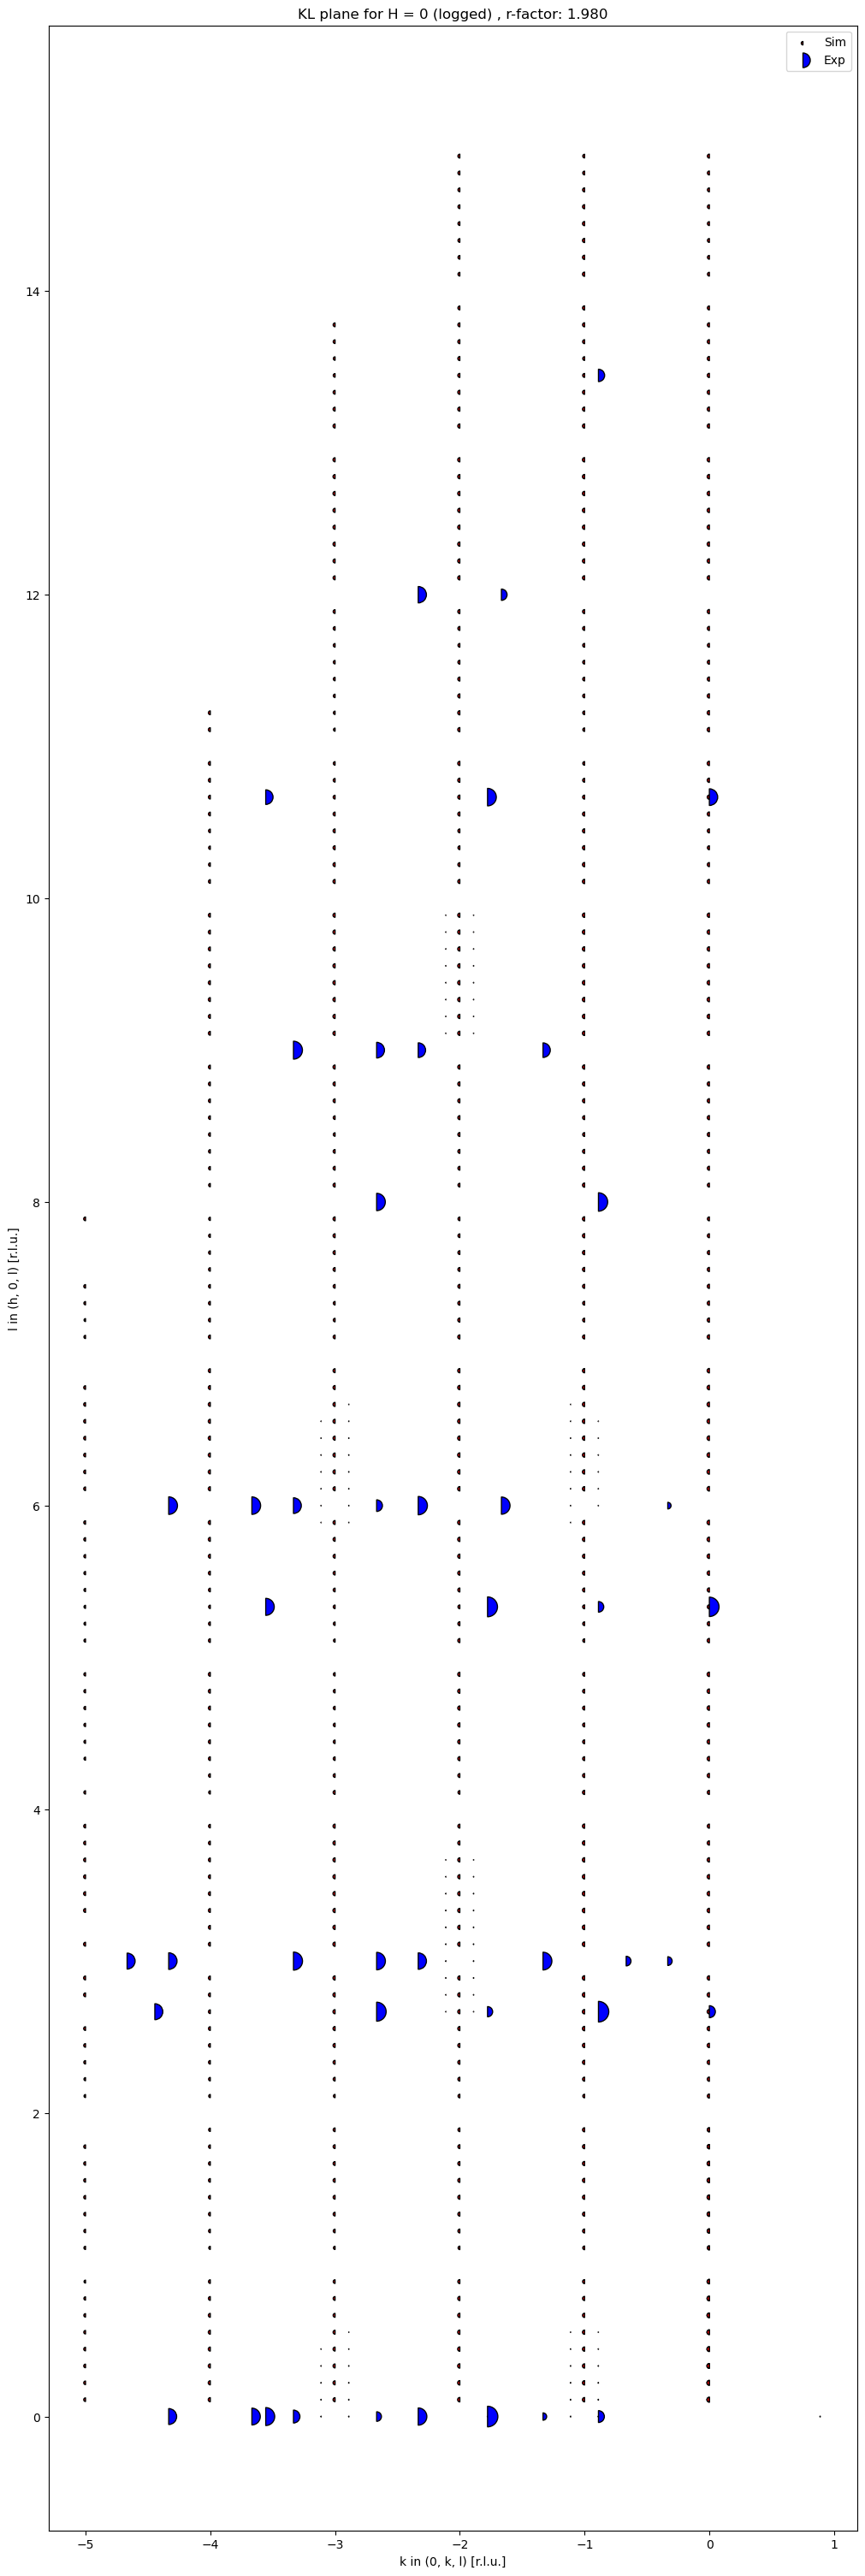

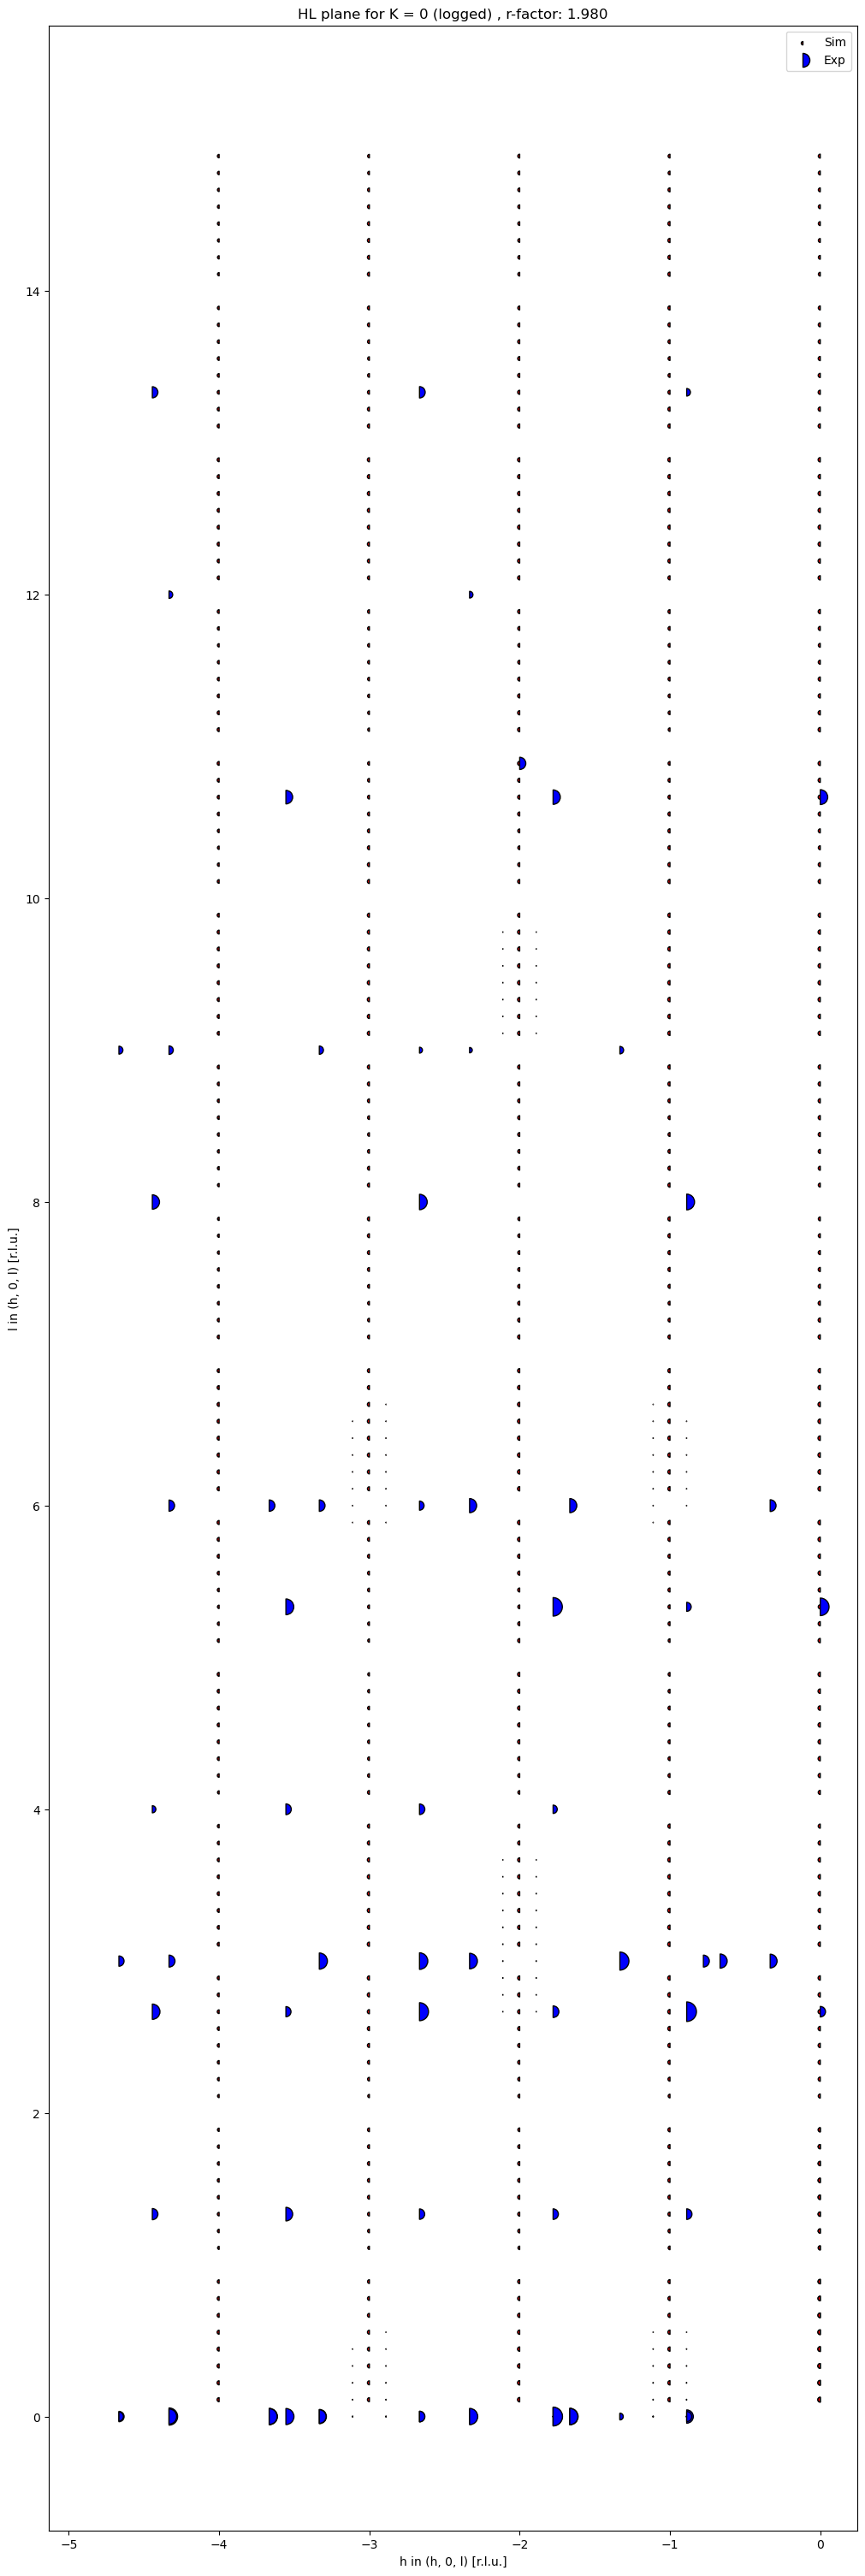

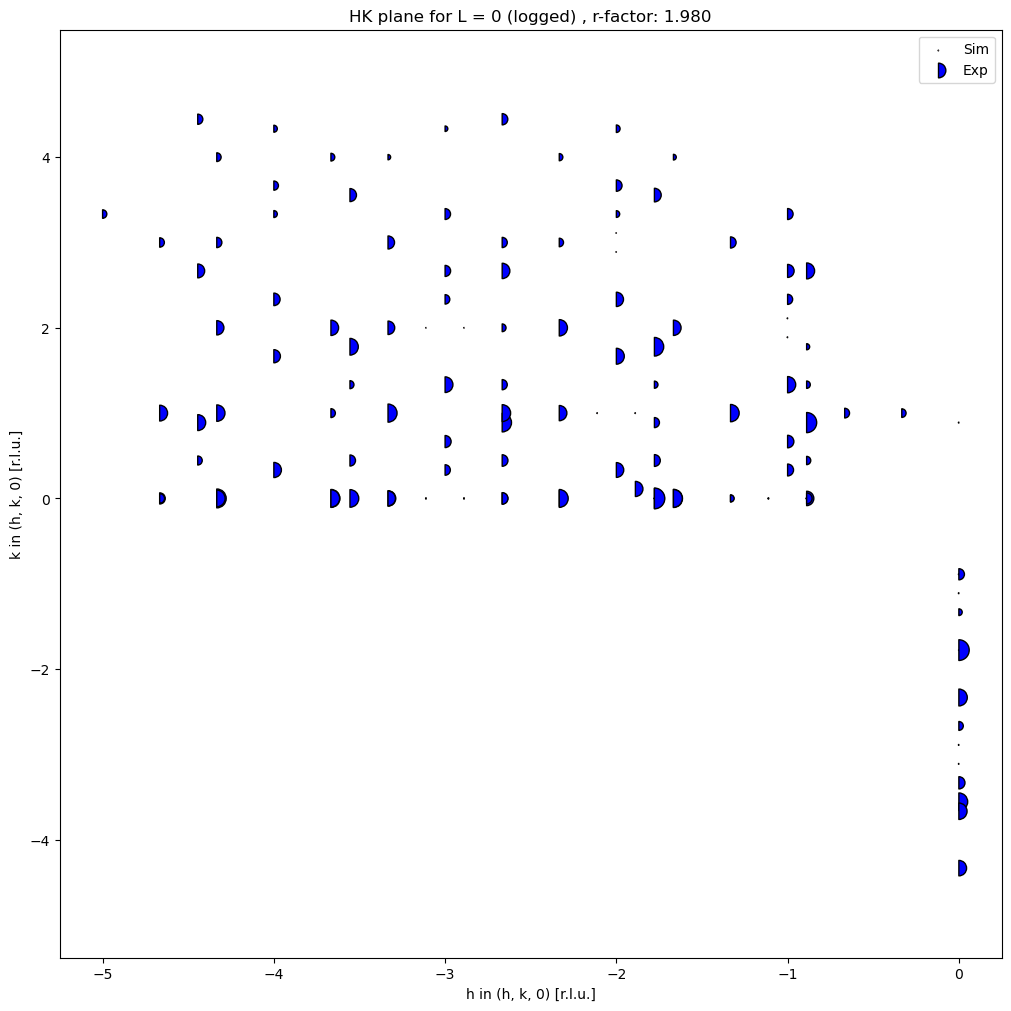

In [20]:
fig, axs = plt.subplots(1, 1, figsize=(10,30), constrained_layout=True)

plot_plane_sim_vs_exp_DIM1(axs, exp_data, r_factor,norm_plane=True)
plt.show()
fig, axs = plt.subplots(1, 1, figsize=(10,30), constrained_layout=True)
plot_plane_sim_vs_exp_DIM2(axs, exp_data, r_factor,norm_plane=True)
plt.show()
fig, axs = plt.subplots(1, 1, figsize=(10,10), constrained_layout=True)
plot_plane_sim_vs_exp_DIM3(axs, exp_data, r_factor, 0,norm_plane=True)
plt.show()


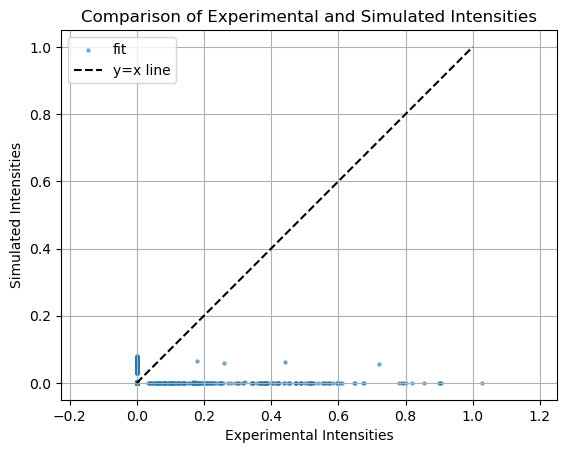

In [21]:
x = np.linspace(0 ,1, 10000)
y = x
plt.scatter(exp_data['intensity_exp']/np.sum(exp_data['intensity_exp']) * 60, exp_data['intensity_sim'], s=5, alpha=0.5 , label='fit')
plt.plot(x , y, color='black', linestyle='--', label='y=x line')
plt.legend()
plt.grid(True)
plt.title('Comparison of Experimental and Simulated Intensities')
plt.xlabel('Experimental Intensities')
plt.ylabel('Simulated Intensities')
plt.axis('equal')
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import pandas as pd
from visualiser_function1 import transform_list_hkl_p63_p65, transform_list_hkl_p63_p65, get_structure_factors , atom_position_list
from itertools import chain
from matplotlib.markers import MarkerStyle
from tqdm import tqdm
from time import time